# LUAD Survival Analysis — DeepSurv
**Author:** Parth Shringarpure  
**Date:** June 2026  
**Goal:** Build a deep learning survival model (DeepSurv) using PyTorch.
Train with Cox partial likelihood loss on 1,000 gene expression features.
Beat the Cox-Lasso baseline of 0.65 and ideally the clinical baseline of 0.70.

## Baseline Scores to Beat
| Model | Features | C-index |
|---|---|---|
| Cox clinical | age, stage, gender | 0.70 |
| Cox-Lasso expression | 72 genes | 0.65 |
| **DeepSurv** | **1,000 genes** | **???** |

## Step 1: Imports and Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.chdir('/Users/parthshringarpure/Desktop/Projects/luad_survival')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from lifelines.utils import concordance_index

# Set random seeds for reproducibility
# This ensures you get the same results every time you run
torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
print(f"Device available: {'GPU' if torch.cuda.is_available() else 'CPU (Mac)'}")

PyTorch version: 2.12.0
Device available: CPU (Mac)


## Step 2: Load and Prepare Data

In [2]:
# Load data
expression = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)
clinical   = pd.read_csv('data/processed/clinical_survival.csv', index_col=0)

# Align patients
common     = clinical.index.intersection(expression.index)
expression = expression.loc[common]
clinical   = clinical.loc[common]

print(f"Patients: {len(common)}")
print(f"Genes:    {expression.shape[1]}")
print(f"Events:   {clinical['event'].sum()} deaths ({clinical['event'].mean():.1%})")

Patients: 478
Genes:    1000
Events:   121 deaths (25.3%)


## Step 3: Train / Validation / Test Split and Scaling

In [3]:
# Extract features and labels
X = expression.values.astype(np.float32)
y_time  = clinical['survival_time'].values.astype(np.float32)
y_event = clinical['event'].values.astype(np.float32)

# Split — same proportions as Cox-Lasso for fair comparison
X_temp,  X_test,  y_time_temp,  y_time_test, y_event_temp, y_event_test = train_test_split(
    X, y_time, y_event, test_size=0.15, random_state=42
)
X_train, X_val, y_time_train, y_time_val, y_event_train, y_event_val = train_test_split(
    X_temp, y_time_temp, y_event_temp, test_size=0.176, random_state=42
)

# Scale features
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

print(f"Train: {X_train.shape[0]} patients")
print(f"Val:   {X_val.shape[0]} patients")
print(f"Test:  {X_test.shape[0]} patients")

Train: 334 patients
Val:   72 patients
Test:  72 patients


## Step 4: Build the DeepSurv Model

Architecture: 1000 → 256 → 128 → 64 → 1
- ReLU activations between layers
- Batch normalisation to stabilise training
- Dropout (0.3) to prevent overfitting
- Single output neuron = risk score (no activation)

In [4]:
class DeepSurv(nn.Module):
    def __init__(self, input_dim, hidden_dims, dropout):
        super(DeepSurv, self).__init__()

        # Build layers dynamically from hidden_dims list
        layers = []
        prev_dim = input_dim

        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))  # fully connected layer
            layers.append(nn.BatchNorm1d(hidden_dim))        # stabilise training
            layers.append(nn.ReLU())                         # non-linearity
            layers.append(nn.Dropout(dropout))               # regularisation
            prev_dim = hidden_dim

        # Final output layer — single risk score per patient
        layers.append(nn.Linear(prev_dim, 1))

        # Combine all layers into a sequential model
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        # Pass input through all layers
        return self.network(x).squeeze()  # squeeze removes extra dimension

# Instantiate the model
model = DeepSurv(
    input_dim   = 1000,
    hidden_dims = [256, 128, 64],
    dropout     = 0.3
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

DeepSurv(
  (network): Sequential(
    (0): Linear(in_features=1000, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total parameters: 298,369
Trainable parameters: 298,369


## Step 5: Cox Partial Likelihood Loss Function

The loss function is the heart of DeepSurv.
For each patient who died, the model should assign them 
a higher risk score than all patients still alive at that moment.

Mathematical intuition:
- At each death event, look at all patients still alive (risk set)
- Loss penalises the model if the dying patient's risk score
  is not higher than others in the risk set
- Minimising this loss = maximising the C-index

In [5]:
def cox_partial_likelihood_loss(risk_scores, survival_times, events):
    """
    Cox partial likelihood loss.
    
    Args:
        risk_scores:    model output, shape (n_patients,)
        survival_times: days survived, shape (n_patients,)
        events:         1=died, 0=censored, shape (n_patients,)
    
    Returns:
        scalar loss value
    """
    # Sort everything by survival time descending
    # This makes computing the risk set efficient
    order = torch.argsort(survival_times, descending=True)
    risk_scores    = risk_scores[order]
    events         = events[order]

    # For numerical stability — subtract max risk score
    # This prevents exp() from overflowing
    risk_scores = risk_scores - risk_scores.max()

    # Cumulative sum of exp(risk scores)
    # At position i this gives sum of exp(risk) for all patients
    # with survival_time >= survival_time[i]
    # This is the risk set for patient i
    log_cumsum = torch.log(torch.cumsum(torch.exp(risk_scores), dim=0))

    # Cox partial likelihood for each death event:
    # log likelihood = risk_score_of_dying_patient
    #                  - log(sum of exp(risk) in risk set)
    # We only compute this for patients who actually died (events==1)
    loss = -torch.mean((risk_scores - log_cumsum) * events)

    return loss

print("Cox partial likelihood loss function defined")
print("\nHow it works:")
print("  For each death → loss increases if dying patient's risk")
print("  score is NOT higher than surviving patients at that moment")
print("  Minimising loss → model learns to rank patients correctly")

Cox partial likelihood loss function defined

How it works:
  For each death → loss increases if dying patient's risk
  score is NOT higher than surviving patients at that moment
  Minimising loss → model learns to rank patients correctly


## Step 6: PyTorch Dataset and DataLoader

PyTorch needs data wrapped in a Dataset object.
DataLoader then feeds it to the model in batches during training.

In [6]:
class SurvivalDataset(Dataset):
    def __init__(self, X, y_time, y_event):
        # Convert numpy arrays to PyTorch tensors
        self.X       = torch.FloatTensor(X)
        self.y_time  = torch.FloatTensor(y_time)
        self.y_event = torch.FloatTensor(y_event)

    def __len__(self):
        # How many patients in this dataset
        return len(self.X)

    def __getitem__(self, idx):
        # Return one patient's data by index
        return self.X[idx], self.y_time[idx], self.y_event[idx]

# Create datasets
train_dataset = SurvivalDataset(X_train, y_time_train, y_event_train)
val_dataset   = SurvivalDataset(X_val,   y_time_val,   y_event_val)
test_dataset  = SurvivalDataset(X_test,  y_time_test,  y_event_test)

# Create dataloaders
# shuffle=True for training — randomise patient order each epoch
# shuffle=False for val/test — order doesn't matter for evaluation
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=72, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=72, shuffle=False)

print(f"Train batches per epoch: {len(train_loader)}")
print(f"Train patients:          {len(train_dataset)}")
print(f"Val patients:            {len(val_dataset)}")
print(f"Test patients:           {len(test_dataset)}")

Train batches per epoch: 6
Train patients:          334
Val patients:            72
Test patients:           72


## Step 7: Training Loop

We train for up to 200 epochs with early stopping.
Early stopping monitors validation C-index and stops training
if it doesn't improve for 20 consecutive epochs.
This prevents overfitting and saves the best model automatically.

In [8]:
# Initialise optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate scheduler — reduces LR when validation plateaus
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10
)

# Training history — for plotting later
history = {
    'train_loss'   : [],
    'val_cindex'   : [],
    'best_epoch'   : 0,
    'best_cindex'  : 0.0
}

# Early stopping settings
PATIENCE    = 20
MAX_EPOCHS  = 200
best_weights = None
no_improve   = 0

print("Starting training...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val C-index':>12} {'Best':>6}")
print("-" * 45)

for epoch in range(1, MAX_EPOCHS + 1):

    # ── TRAINING PHASE ──────────────────────────────
    model.train()  # activates dropout and batchnorm training mode
    epoch_loss = 0.0

    for X_batch, t_batch, e_batch in train_loader:
        optimizer.zero_grad()                          # clear previous gradients
        risk = model(X_batch)                          # forward pass
        loss = cox_partial_likelihood_loss(risk, t_batch, e_batch)  # compute loss
        loss.backward()                                # backward pass
        optimizer.step()                               # update weights
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    # ── VALIDATION PHASE ────────────────────────────
    model.eval()  # deactivates dropout
    with torch.no_grad():  # no gradient computation needed
        X_val_t = torch.FloatTensor(X_val)
        val_risk = model(X_val_t).numpy()

    val_cindex = concordance_index(y_time_val, -val_risk, y_event_val)

    # Update scheduler
    scheduler.step(val_cindex)

    # Save history
    history['train_loss'].append(avg_loss)
    history['val_cindex'].append(val_cindex)

    # Check if best model
    is_best = val_cindex > history['best_cindex']
    if is_best:
        history['best_cindex'] = val_cindex
        history['best_epoch']  = epoch
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    # Print every 10 epochs
    if epoch % 10 == 0 or epoch == 1:
        marker = '★' if is_best else ''
        print(f"{epoch:>6} {avg_loss:>12.4f} {val_cindex:>12.4f} {marker}")

    # Early stopping
    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {history['best_epoch']}, Best val C-index: {history['best_cindex']:.4f}")
        break

# Restore best weights
model.load_state_dict(best_weights)
print(f"\nBest model restored from epoch {history['best_epoch']}")

Starting training...
 Epoch   Train Loss  Val C-index   Best
---------------------------------------------
     1       0.6334       0.7118 ★
    10       0.4149       0.6995 
    20       0.3200       0.7438 ★
    30       0.2654       0.6847 
    40       0.2575       0.7389 

Early stopping at epoch 40
Best epoch: 20, Best val C-index: 0.7438

Best model restored from epoch 20


## Step 8: Evaluate on Test Set

We now evaluate the best model (epoch 20) on the held-out test set.
This is the only unbiased estimate of true generalisation performance.

In [9]:
model.eval()
with torch.no_grad():
    # Get risk scores for all three sets
    train_risk = model(torch.FloatTensor(X_train)).numpy()
    val_risk   = model(torch.FloatTensor(X_val)).numpy()
    test_risk  = model(torch.FloatTensor(X_test)).numpy()

# Calculate C-index for all three sets
# Note: concordance_index takes negative risk because
# higher risk = shorter survival = lower survival time
train_cindex = concordance_index(y_time_train, -train_risk, y_event_train)
val_cindex   = concordance_index(y_time_val,   -val_risk,   y_event_val)
test_cindex  = concordance_index(y_time_test,  -test_risk,  y_event_test)

print(f"{'='*50}")
print(f"DEEPSURV RESULTS SUMMARY")
print(f"{'='*50}")
print(f"Best epoch:          {history['best_epoch']}")
print(f"Train C-index:       {train_cindex:.4f}")
print(f"Val C-index:         {val_cindex:.4f}")
print(f"Test C-index:        {test_cindex:.4f}")
print(f"{'='*50}")
print(f"\nMODEL COMPARISON:")
print(f"  Cox clinical:          0.7001")
print(f"  Cox-Lasso expression:  0.6493")
print(f"  DeepSurv expression:   {test_cindex:.4f}")
diff_clinical = test_cindex - 0.7001
diff_lasso    = test_cindex - 0.6493
print(f"\n  vs Cox clinical:       {diff_clinical:+.4f}")
print(f"  vs Cox-Lasso:          {diff_lasso:+.4f}")

DEEPSURV RESULTS SUMMARY
Best epoch:          20
Train C-index:       0.9654
Val C-index:         0.7438
Test C-index:        0.5721

MODEL COMPARISON:
  Cox clinical:          0.7001
  Cox-Lasso expression:  0.6493
  DeepSurv expression:   0.5721

  vs Cox clinical:       -0.1280
  vs Cox-Lasso:          -0.0772


## Step 9: Rebuild with Stronger Regularisation

Original model severely overfit (train=0.97, test=0.57).
Root cause: 298,369 parameters for only 334 training patients.

Fixes:
- Smaller network: 1000 → 64 → 32 → 1
- Higher dropout: 0.5
- Stronger L2 penalty: weight_decay=1e-3
- Longer patience: 30 epochs

In [10]:
# Rebuild smaller model
model = DeepSurv(
    input_dim   = 1000,
    hidden_dims = [64, 32],
    dropout     = 0.5
)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

# Reinitialise optimizer with stronger L2
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001,
    weight_decay=1e-3   # stronger L2 penalty
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=10
)

# Reset history
history = {
    'train_loss'  : [],
    'val_cindex'  : [],
    'best_epoch'  : 0,
    'best_cindex' : 0.0
}

PATIENCE   = 30
MAX_EPOCHS = 300
best_weights = None
no_improve   = 0

print("\nStarting training with smaller model...")
print(f"{'Epoch':>6} {'Train Loss':>12} {'Val C-index':>12} {'Best':>6}")
print("-" * 45)

for epoch in range(1, MAX_EPOCHS + 1):

    # Training phase
    model.train()
    epoch_loss = 0.0

    for X_batch, t_batch, e_batch in train_loader:
        optimizer.zero_grad()
        risk = model(X_batch)
        loss = cox_partial_likelihood_loss(risk, t_batch, e_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    # Validation phase
    model.eval()
    with torch.no_grad():
        val_risk   = model(torch.FloatTensor(X_val)).numpy()

    val_cindex = concordance_index(y_time_val, -val_risk, y_event_val)
    scheduler.step(val_cindex)

    history['train_loss'].append(avg_loss)
    history['val_cindex'].append(val_cindex)

    is_best = val_cindex > history['best_cindex']
    if is_best:
        history['best_cindex'] = val_cindex
        history['best_epoch']  = epoch
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        no_improve   = 0
    else:
        no_improve += 1

    if epoch % 20 == 0 or epoch == 1:
        marker = '★' if is_best else ''
        print(f"{epoch:>6} {avg_loss:>12.4f} {val_cindex:>12.4f} {marker}")

    if no_improve >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {history['best_epoch']}, Best val C-index: {history['best_cindex']:.4f}")
        break

model.load_state_dict(best_weights)
print(f"\nBest model restored from epoch {history['best_epoch']}")

DeepSurv(
  (network): Sequential(
    (0): Linear(in_features=1000, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Total parameters: 66,369

Starting training with smaller model...
 Epoch   Train Loss  Val C-index   Best
---------------------------------------------
     1       0.6804       0.6527 ★
    20       0.5029       0.6921 

Early stopping at epoch 32
Best epoch: 2, Best val C-index: 0.7340

Best model restored from epoch 2


In [11]:
model.eval()
with torch.no_grad():
    train_risk = model(torch.FloatTensor(X_train)).numpy()
    val_risk   = model(torch.FloatTensor(X_val)).numpy()
    test_risk  = model(torch.FloatTensor(X_test)).numpy()

train_cindex = concordance_index(y_time_train, -train_risk, y_event_train)
val_cindex   = concordance_index(y_time_val,   -val_risk,   y_event_val)
test_cindex  = concordance_index(y_time_test,  -test_risk,  y_event_test)

print(f"{'='*50}")
print(f"DEEPSURV v2 RESULTS SUMMARY")
print(f"{'='*50}")
print(f"Best epoch:          {history['best_epoch']}")
print(f"Train C-index:       {train_cindex:.4f}")
print(f"Val C-index:         {val_cindex:.4f}")
print(f"Test C-index:        {test_cindex:.4f}")
print(f"Train-Test gap:      {train_cindex - test_cindex:.4f}")
print(f"{'='*50}")
print(f"\nMODEL COMPARISON:")
print(f"  Cox clinical:          0.7001")
print(f"  Cox-Lasso expression:  0.6493")
print(f"  DeepSurv v1:           0.5721  (overfit)")
print(f"  DeepSurv v2:           {test_cindex:.4f}")

DEEPSURV v2 RESULTS SUMMARY
Best epoch:          2
Train C-index:       0.7400
Val C-index:         0.7340
Test C-index:        0.5970
Train-Test gap:      0.1430

MODEL COMPARISON:
  Cox clinical:          0.7001
  Cox-Lasso expression:  0.6493
  DeepSurv v1:           0.5721  (overfit)
  DeepSurv v2:           0.5970


## Step 10: Cross-Validated DeepSurv

Single test split (72 patients, 19 events) is too small for stable evaluation.
We use 5-fold cross-validation — train/evaluate 5 times on different splits.
Average C-index across folds gives a much more reliable performance estimate.

In [12]:
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)

fold_cindices = []

print("Running 5-fold cross-validation...")
print(f"{'Fold':>6} {'Best Epoch':>12} {'Val C-index':>12}")
print("-" * 35)

X_all      = np.vstack([X_train, X_val, X_test])
y_time_all  = np.concatenate([y_time_train, y_time_val, y_time_test])
y_event_all = np.concatenate([y_event_train, y_event_val, y_event_test])

for fold, (train_idx, val_idx) in enumerate(kf.split(X_all)):

    # Split data
    X_f_train = X_all[train_idx]
    X_f_val   = X_all[val_idx]
    t_f_train = y_time_all[train_idx]
    t_f_val   = y_time_all[val_idx]
    e_f_train = y_event_all[train_idx]
    e_f_val   = y_event_all[val_idx]

    # Scale within fold — fit on train only
    fold_scaler  = StandardScaler()
    X_f_train = fold_scaler.fit_transform(X_f_train)
    X_f_val   = fold_scaler.transform(X_f_val)

    # Build fresh model for each fold
    fold_model = DeepSurv(
        input_dim   = 1000,
        hidden_dims = [64, 32],
        dropout     = 0.5
    )
    fold_optimizer = torch.optim.Adam(
        fold_model.parameters(),
        lr=0.001,
        weight_decay=1e-3
    )

    # Dataset and loader
    fold_dataset = SurvivalDataset(X_f_train, t_f_train, e_f_train)
    fold_loader  = DataLoader(fold_dataset, batch_size=64, shuffle=True)

    # Train
    best_fold_cindex = 0.0
    best_fold_weights = None
    no_improve = 0

    for epoch in range(1, 200):
        fold_model.train()
        for X_batch, t_batch, e_batch in fold_loader:
            fold_optimizer.zero_grad()
            risk = fold_model(X_batch)
            loss = cox_partial_likelihood_loss(risk, t_batch, e_batch)
            loss.backward()
            fold_optimizer.step()

        fold_model.eval()
        with torch.no_grad():
            val_risk = fold_model(torch.FloatTensor(X_f_val)).numpy()

        cindex = concordance_index(t_f_val, -val_risk, e_f_val)

        if cindex > best_fold_cindex:
            best_fold_cindex  = cindex
            best_fold_weights = {k: v.clone() for k, v in fold_model.state_dict().items()}
            best_epoch        = epoch
            no_improve        = 0
        else:
            no_improve += 1

        if no_improve >= 20:
            break

    fold_cindices.append(best_fold_cindex)
    print(f"{fold+1:>6} {best_epoch:>12} {best_fold_cindex:>12.4f}")

mean_cindex = np.mean(fold_cindices)
std_cindex  = np.std(fold_cindices)

print(f"\n{'='*50}")
print(f"DEEPSURV 5-FOLD CV RESULTS")
print(f"{'='*50}")
print(f"Fold C-indices: {[f'{c:.4f}' for c in fold_cindices]}")
print(f"Mean C-index:   {mean_cindex:.4f} ± {std_cindex:.4f}")
print(f"{'='*50}")
print(f"\nMODEL COMPARISON:")
print(f"  Cox clinical:          0.7001")
print(f"  Cox-Lasso expression:  0.6493")
print(f"  DeepSurv (5-fold CV):  {mean_cindex:.4f} ± {std_cindex:.4f}")

Running 5-fold cross-validation...
  Fold   Best Epoch  Val C-index
-----------------------------------
     1           32       0.6667
     2           35       0.8089
     3            1       0.6667
     4           37       0.7787
     5           38       0.6402

DEEPSURV 5-FOLD CV RESULTS
Fold C-indices: ['0.6667', '0.8089', '0.6667', '0.7787', '0.6402']
Mean C-index:   0.7122 ± 0.0680

MODEL COMPARISON:
  Cox clinical:          0.7001
  Cox-Lasso expression:  0.6493
  DeepSurv (5-fold CV):  0.7122 ± 0.0680


## Step 11: Save Results and Plot Training History

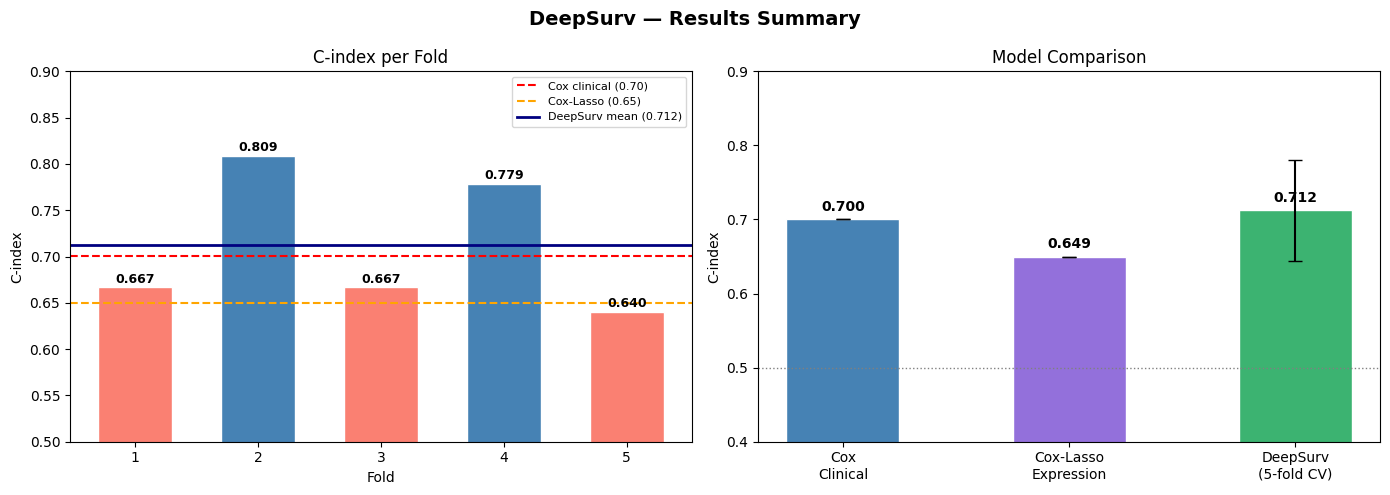

Saved: outputs/figures/05_deepsurv_results.png
Saved: outputs/results/model_comparison.csv

Final scoreboard:
  Cox clinical:         0.700
  Cox-Lasso expression: 0.649
  DeepSurv (CV):        0.712 ± 0.068


In [13]:
# Plot fold C-indices
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DeepSurv — Results Summary', fontweight='bold', fontsize=14)

# Plot 1 — Fold C-indices
ax = axes[0]
fold_nums = list(range(1, 6))
colors = ['salmon' if c < 0.70 else 'steelblue' for c in fold_cindices]
bars = ax.bar(fold_nums, fold_cindices, color=colors, edgecolor='white', width=0.6)
ax.axhline(0.7001, color='red',      linestyle='--', linewidth=1.5, label='Cox clinical (0.70)')
ax.axhline(0.6493, color='orange',   linestyle='--', linewidth=1.5, label='Cox-Lasso (0.65)')
ax.axhline(mean_cindex, color='navy', linestyle='-', linewidth=2,   label=f'DeepSurv mean ({mean_cindex:.3f})')
ax.set_xlabel('Fold')
ax.set_ylabel('C-index')
ax.set_title('C-index per Fold')
ax.set_ylim(0.5, 0.9)
ax.legend(fontsize=8)
for bar, val in zip(bars, fold_cindices):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2 — Model comparison
ax = axes[1]
models  = ['Cox\nClinical', 'Cox-Lasso\nExpression', 'DeepSurv\n(5-fold CV)']
scores  = [0.7001, 0.6493, mean_cindex]
errors  = [0, 0, std_cindex]
colors2 = ['steelblue', 'mediumpurple', 'mediumseagreen']
bars2 = ax.bar(models, scores, color=colors2, edgecolor='white',
               yerr=errors, capsize=5, width=0.5)
ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, label='Random (0.50)')
ax.set_ylabel('C-index')
ax.set_title('Model Comparison')
ax.set_ylim(0.4, 0.9)
for bar, val in zip(bars2, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.012,
            f'{val:.3f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/figures/05_deepsurv_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Save numerical results
results_df = pd.DataFrame({
    'model'    : ['Cox Clinical', 'Cox-Lasso Expression', 'DeepSurv 5-fold CV'],
    'features' : ['age, stage, gender', '72 genes', '1000 genes'],
    'c_index'  : [0.7001, 0.6493, mean_cindex],
    'std'      : [None, None, std_cindex]
})
results_df.to_csv('outputs/results/model_comparison.csv', index=False)

print("Saved: outputs/figures/05_deepsurv_results.png")
print("Saved: outputs/results/model_comparison.csv")
print(f"\nFinal scoreboard:")
print(f"  Cox clinical:         0.700")
print(f"  Cox-Lasso expression: 0.649")
print(f"  DeepSurv (CV):        {mean_cindex:.3f} ± {std_cindex:.3f}")